In [1]:
import numpy as np
import matplotlib.pyplot as plt

<h1>User Input</h1>

In [6]:
# Transformation matrix (change this to anything you want)
A = np.array([
    [1.2, -0.4],
    [0.6,  1.1]
])

# Points to transform (columns are points)
#points = np.array([
#    [1, 2, -1],
#    [1, -1, 0]
#])

points = np.array([
    [1, -1],
    [1, 2]
])


90 degree right rotate

In [9]:
# Transformation matrix (change this to anything you want)
A = np.array([
    [0, 1],
    [-1,  0]
])

# Points to transform (columns are points)
#points = np.array([
#    [1, 2, -1],
#    [1, -1, 0]
#])

points = np.array([
    [1, -1],
    [1, 2]
])


<h1>Helper Functions</h1>

In [10]:
def plot_grid(ax, color, alpha=0.4, lw=1):
    """Draws a grid of lines in R^2."""
    grid_range = np.linspace(-3, 3, 13)
    for x in grid_range:
        ax.plot([-3, 3], [x, x], color=color, alpha=alpha, lw=lw)
        ax.plot([x, x], [-3, 3], color=color, alpha=alpha, lw=lw)

def transform_grid(A, ax, color, alpha=0.7, lw=1):
    """Draws image of the grid under linear transformation A."""
    grid_range = np.linspace(-3, 3, 13)
    for x in grid_range:
        line_x = np.vstack((np.linspace(-3, 3, 50), np.ones(50)*x))
        line_y = np.vstack((np.ones(50)*x, np.linspace(-3, 3, 50)))
        line_x_t = A @ line_x
        line_y_t = A @ line_y
        ax.plot(line_x_t[0], line_x_t[1], color=color, alpha=alpha, lw=lw)
        ax.plot(line_y_t[0], line_y_t[1], color=color, alpha=alpha, lw=lw)

def plot_points(ax, pts, labels, color):
    """Plot 2D points with labels."""
    ax.scatter(pts[0], pts[1], s=60, color=color)
    for i, label in enumerate(labels):
        ax.text(pts[0, i] + 0.05, pts[1, i] + 0.05, label, color=color, fontsize=12)


<h1>Helper Functions</h1>

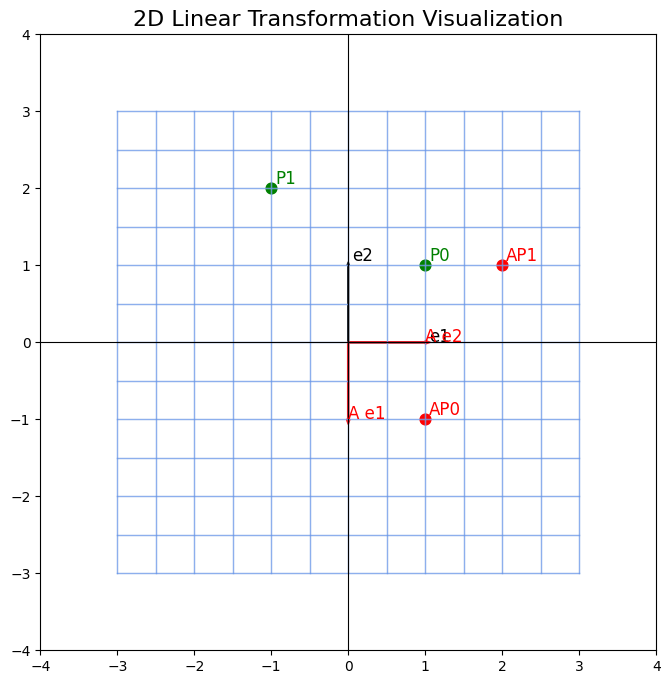

In [11]:
# ---------------------------------------------------------
# PREP FIGURE
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")

# ---------------------------------------------------------
# ORIGINAL GRID
# ---------------------------------------------------------
plot_grid(ax, color="lightgray")

# ---------------------------------------------------------
# TRANSFORMED GRID
# ---------------------------------------------------------
transform_grid(A, ax, color="cornflowerblue")

# ---------------------------------------------------------
# BASIS VECTORS BEFORE & AFTER
# ---------------------------------------------------------
e1 = np.array([[1, 0], [0, 1]])
Ae1 = A @ e1

# original basis
ax.arrow(0, 0, 1, 0, color="black", width=0.01)
ax.arrow(0, 0, 0, 1, color="black", width=0.01)
ax.text(1.05, 0, "e1", fontsize=12)
ax.text(0.05, 1.05, "e2", fontsize=12)

# transformed basis
ax.arrow(0, 0, Ae1[0, 0], Ae1[1, 0], color="red", width=0.015)
ax.arrow(0, 0, Ae1[0, 1], Ae1[1, 1], color="red", width=0.015)
ax.text(Ae1[0, 0], Ae1[1, 0], "A e1", color="red", fontsize=12)
ax.text(Ae1[0, 1], Ae1[1, 1], "A e2", color="red", fontsize=12)

# ---------------------------------------------------------
# POINTS BEFORE AND AFTER TRANSFORMATION
# ---------------------------------------------------------
transformed_points = A @ points
labels = [f"P{i}" for i in range(points.shape[1])]

plot_points(ax, points, labels, color="green")            # original points
plot_points(ax, transformed_points, [f"A{l}" for l in labels], color="red")  # transformed

# ---------------------------------------------------------
# STYLE
# ---------------------------------------------------------
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("2D Linear Transformation Visualization", fontsize=16)

plt.show()